# Observation simulation

In this tutorial, we will simulate the observation of the Draco dwarf spheroidal galaxy (dSph) using Gammapy. We focus on Dark Matter (DM) annihilation signals using theoretical density profiles and the Instrument Response Functions (IRFs) for the CTA (Cherenkov Telescope Array).

In [ ]:
from gammapy.data import Observation
from gammapy.datasets import MapDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import (
    MapDatasetMaker,
    SafeMaskMaker
)
from gammapy.maps import MapAxis, WcsGeom, WcsNDMap
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    PointSpatialModel
)
from gammapy.astro.darkmatter import (
    DarkMatterAnnihilationSpectralModel
)
from gammapy.astro.darkmatter.profiles import EinastoProfile

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib

# Set the spectra data storage for Gammapy
os.environ["GAMMAPY_DATA"] = r"/Users/alexcervino/Desktop/DARKMATTER/gammapy-data/"

#In this case the spectra modelling file can be from PPPC4ID or CosmiXs
dm_path = pathlib.Path(os.environ["GAMMAPY_DATA"]) / "dark_matter_spectra"/"PPPC4DMID" / "AtProduction_gammas.dat"
print("Full DM file path =", dm_path)
print("File exists?       =", dm_path.exists())


Full DM file path = /Users/alexcervino/Desktop/DARKMATTER/gammapy-data/dark_matter_spectra/PPPC4DMID/AtProduction_gammas.dat
File exists?       = True


### Target source

We define our target source. For a realistic simulation, we need to know the object's elevation in the sky from the telescope's location at a specific time. This affects which IRF (zenith angle dependent) we should use.

In [2]:
# Source coordinates
draco_pos = SkyCoord(ra=260.05167 * u.deg, dec=57.915 * u.deg, frame="icrs")
draco_dist = 76 * u.kpc

print("Source coordinates:")
print(draco_pos.to_string('hmsdms'))
print(f"Distance: {draco_dist}")

# Location coordinates, i.e CTA-North
cta_norte = EarthLocation(lat=28.762 * u.deg, lon=-17.89 * u.deg, height=2200 * u.m)  

# Observation start time
obs_time = Time("2025-06-17 01:00:00")  # UTC

altaz = AltAz(obstime=obs_time, location=cta_norte)
draco_altaz = draco_pos.transform_to(altaz)

# Altitude and zenith angle
altitude = draco_altaz.alt.deg
zenith_angle = 90 - altitude

print(f"Altitude: {altitude:.2f}°")
print(f"Zenith angle: {zenith_angle:.2f}°")

Source coordinates:
17h20m12.4008s +57d54m54s
Distance: 76.0 kpc


/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)


Altitude: 60.82°
Zenith angle: 29.18°


For the simulation we need to define several points:

### Dark Matter model parameters
We define the particle physics properties: the annihilation channel (e.g., h bosons), the particle mass, and the J-Factor (the line-of-sight integral of the DM density squared).

In [3]:
# Simulation
# DM parameters: mass and channel
channel = "h"
massDM = 10 * u.TeV

# Density profile
rho_s_msun_kpc3 = 1.3e7 * (u.M_sun / u.kpc**3)  
# From M_sun/kpc³ to GeV/cm³
rho_s_GeV_cm3 = rho_s_msun_kpc3.to(u.GeV / u.cm**3, equivalencies=u.mass_energy())

# Jfactor
jfact_draco = 1.66e23 * u.GeV**2 / u.cm**5 #Multiplied by a number from which the signal will be detected, in this case is 5

draco_profile = EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV_cm3
)

### Map geometry and energy range
We define the energy range for the simulation and the spatial resolution of our World Coordinate System (WCS) map.

In [4]:
# Set energy bounds
energy_edges = np.logspace(-1, 2, 15) 
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
energy_true = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

# Geometry map
geom_draco = WcsGeom.create(
    skydir=draco_pos,
    binsz=0.01,
    width=5.0,
    frame="icrs",
    axes=[energy_reco]  
)

### Sky model
We combine the spatial model (treating Draco as a point source) with the DM annihilation spectral model. 

The Spatial Model defines the shape and position of our target. We use a PointSpatialModel centered on Draco. While DM halos are technically extended, Draco is compact enough that a point-source approximation is a standard starting point relative to the telescope's resolution.

The Spectral Model defines the gamma-ray flux as a function of energy. We use the DarkMatterAnnihilationSpectralModel, which combines Particle Physics (mass and annihilation channel) with Astrophysics (the J-Factor).

In [5]:
# Spatial model
spatial_model = PointSpatialModel(
    lon_0=draco_pos.ra,
    lat_0=draco_pos.dec,
    frame="icrs"
)

# Spectral model
spectral_model = DarkMatterAnnihilationSpectralModel(
    mass=massDM, channel=channel, jfactor=jfact_draco)

# Combined model
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="draco-dm"
)

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


### IRF and observation setup
We load the IRFs (Instrument Response Functions), which represent the "fingerprint" of the telescope. They describe how the instrument distorts the signal: Effective Area (efficiency), PSF (spatial blurring), and Energy Dispersion (energy resolution). In this simulation, they translate our theoretical Dark Matter flux into the realistic "counts" the CTA would actually detect.

In [6]:
# Load CTA Prod5 IRFs
irf_path = r"/Users/alexcervino/Desktop/DARKMATTER/ksp_dsph_material/IRFs/cta/prod5-v0.1/bcf/North_z20_N_50h/Prod5-North-20deg-NorthAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irfs = load_irf_dict_from_file(irf_path)

# Create the Observation: 500 hours of livetime
livetime = 500 * u.h
obs = Observation.create(
    pointing=draco_pos, 
    livetime=livetime, 
    irfs=irfs, 
    reference_time=obs_time
)

/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/gammapy/data/observations.py:303: GammapyDeprecationWarning: Pointing will be required to be provided as FixedPointingInfo
  warnings.warn(


### Simulation
In this final step, we apply the models and IRFs to generate a synthetic event count map.

In [7]:
# 1. Create an empty MapDataset
empty = MapDataset.create(geom=geom_draco, name="dataset-simu-draco", energy_axis_true=energy_true)

# 2. Setup Maker to calculate exposure, background, PSF, and energy dispersion
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=2.5 * u.deg)

# 3. Run the maker and attach models
dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)

# Attach the DM model and a Field-of-View background model
bkg_model = FoVBackgroundModel(dataset_name="dataset-simu-draco")
dataset.models = Models([model_simu, bkg_model])

# 4. Generate the simulation
print(f"Predicted events before simulation: {dataset.npred().data.sum():.2f}")
dataset.fake() # This populates the .counts attribute
print(f"Events after simulation (Poisson realization): {dataset.counts.data.sum()}")

Predicted events before simulation: 27082213.40
Events after simulation (Poisson realization): 27075439.0


# Simulation inspection

interactive(children=(SelectionSlider(continuous_update=False, description='Select energy:', layout=Layout(wid…

/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = 

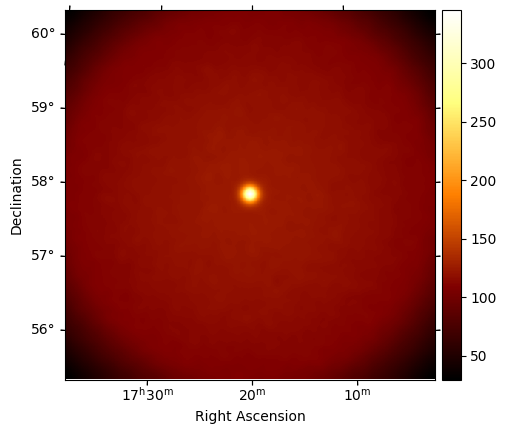

/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = 

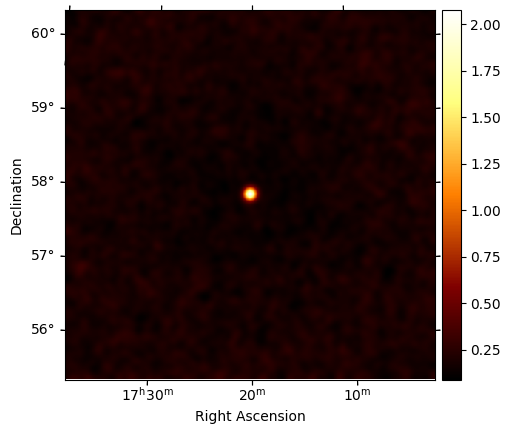

In [8]:
# Check countmaps

#Interactive
dataset.counts.smooth(0.05 * u.deg).plot_interactive(
    add_cbar=True, stretch="linear"
)

plt.show()

# Static
dataset.counts.reduce_over_axes().smooth(0.05 * u.deg).plot(add_cbar=True)
plt.show()

# Setting and energy range for the countmap
energy_min = 3.16 * u.TeV
energy_max = 5.18 * u.TeV

energy_axis = dataset.counts.geom.axes["energy"]

energy_indices = np.where(
    (energy_axis.center >= energy_min) & (energy_axis.center <= energy_max)
)[0]

counts_data = dataset.counts.data
counts_sum = counts_data[energy_indices, :, :].sum(axis=0)

geom_image = dataset.counts.geom.to_image()
counts_map = WcsNDMap(geom=geom_image, data=counts_sum)

smoothed_map = counts_map.smooth(0.05 * u.deg)

fig = smoothed_map.plot(add_cbar=True)
plt.show()


In [9]:
print(dataset)

MapDataset
----------

  Name                            : dataset-simu-draco 

  Total counts                    : 22688400 
  Total background counts         : 22612007.17
  Total excess counts             : 76392.83

  Predicted counts                : 22694718.66
  Predicted background counts     : 22612007.17
  Predicted excess counts         : 82711.48

  Exposure min                    : 1.65e+11 m2 s
  Exposure max                    : 2.40e+12 m2 s

  Number of total bins            : 3500000 
  Number of fit bins              : 2749320 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : -115611499.37

  Number of models                : 2 
  Number of parameters            : 6
  Number of free parameters       : 4

  Component 0: SkyModel
  
    Name                      : draco-dm
    Datasets names            : None
    Spectral model type       : DarkMatterAnnihilationSpectralModel
    Spatial  model type       : PointSpatialModel
    Temporal mo

/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = 

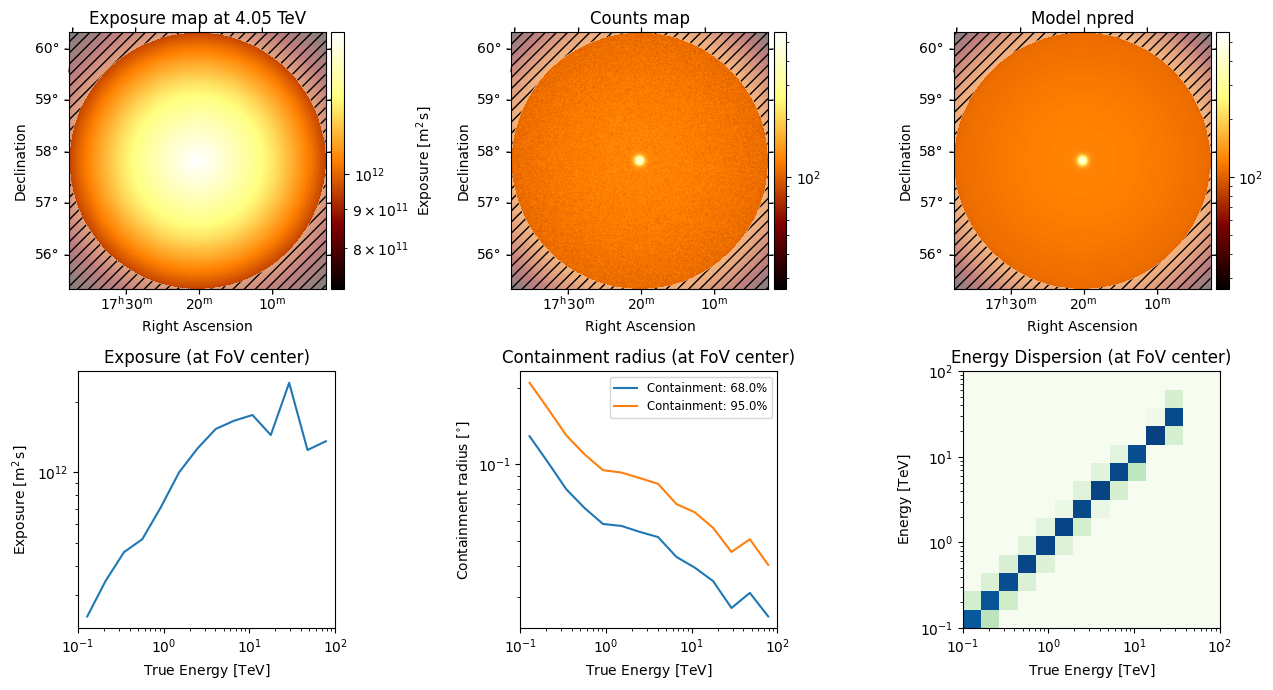

In [10]:
# General check of the dataset
dataset.peek()

### Statistical validation: The background-only hypothesis
To confirm that any detected signal is truly from Dark Matter and not just a statistical fluke of the background, we perform a Null Hypothesis test.

We create a deepcopy of our simulation. This "frozen" copy contains the exact same simulated events (counts) but only knows about the Background model, ignoring the Dark Matter component.

Excess & Significance Estimation: We use the ExcessMapEstimator to correlate the data. The excess map shows the "leftover" counts after subtracting the background model. Since this dataset contains DM events but the model expects only background, we should see a clear excess at Draco's position. The significance map (Li & Ma) converts that excess into standard deviations (σ). This tells us if the "bump" we see is statistically significant or just noise.

In [11]:
#Duplicate the dataset just to store the background model
from copy import deepcopy

dataset_only_bkg = deepcopy(dataset)

# Create background model
bkg_model_only = FoVBackgroundModel(dataset_name=dataset_only_bkg.name)
dataset_only_bkg.models = Models([bkg_model_only])


In [12]:
print(dataset_only_bkg)

MapDataset
----------

  Name                            : dataset-simu-draco 

  Total counts                    : 22688400 
  Total background counts         : 22612007.17
  Total excess counts             : 76392.83

  Predicted counts                : 22612007.17
  Predicted background counts     : 22612007.17
  Predicted excess counts         : nan

  Exposure min                    : 1.65e+11 m2 s
  Exposure max                    : 2.40e+12 m2 s

  Number of total bins            : 3500000 
  Number of fit bins              : 2749320 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : -115480434.99

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 1

  Component 0: FoVBackgroundModel
  
    Name                      : dataset-simu-draco-bkg
    Datasets names            : ['dataset-simu-draco']
    Spectral model type       : PowerLawNormSpectralModel
    Parameters:
      tilt            

/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/gammapy-dev/lib/python3.11/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = 

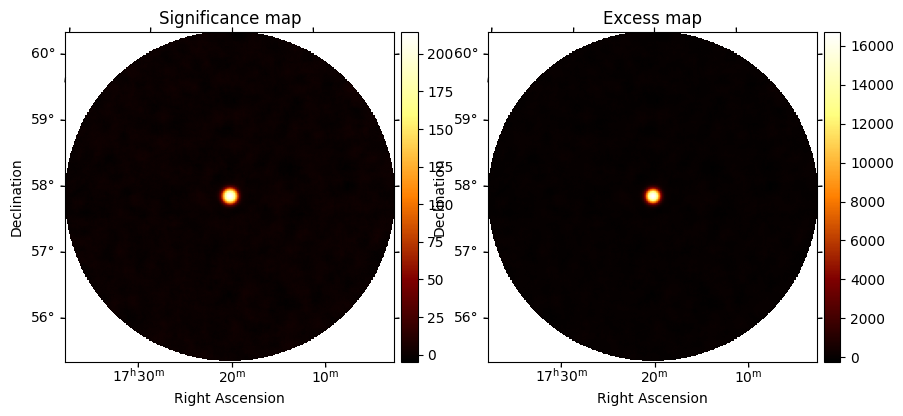

In [13]:
# Excess map and significance
from gammapy.estimators import ExcessMapEstimator

estimator = ExcessMapEstimator(
    0.1 * u.deg, selection_optional=[], energy_edges=[0.4, 1] * u.TeV
)

maps = estimator.run(dataset_only_bkg)

plt.figure(figsize=(10, 10))
ax1 = plt.subplot(121, projection=maps.sqrt_ts.geom.wcs)
ax2 = plt.subplot(122, projection=maps.sqrt_ts.geom.wcs)

ax1.set_title("Significance map")
maps.sqrt_ts.plot(ax=ax1, add_cbar=True)

ax2.set_title("Excess map")
maps.npred_excess.plot(ax=ax2, add_cbar=True)
plt.show()
